# Tarea 2 — WavePsi 3D y Denoising DWT 2D

La implementación de la tarea se realizó en dos bloques:

1. **Parte 1:** evaluación de volúmenes MRI 3D usando métricas clásicas y una métrica perceptual multiescala tipo **WavePsi**.
2. **Parte 2:** **denoising** de imágenes astronómicas con **DWT 2D**, usando distintas wavelets y thresholding duro/suave.

El notebook utiliza los módulos y utilidades del repositorio, para ofercer una implementación limpia, reproducible y consistente con la estructura del curso.

## Estructura del repositorio

```text
proc-multiesc-imgs/
├── src/course_utils/
│   ├── io_utils.py
│   ├── plot_utils.py
│   ├── metrics.py
│   ├── wavepsi.py
│   ├── noise_utils.py
│   └── dwt2d.py
├── notebooks/task2/
├── data/raw/task2/
└── results/task2/
```

Archivos disponibles en `data/raw/task2/`:

- `gt.nii`
- `mask.nii`
- `streaking.nii`
- `reconNDI1.nii`, `reconNDI2.nii`
- `recontv1.nii`, `recontv2.nii`, `recontv3.nii`
- `Moon.png`
- `EX3_01.png`

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if (ROOT / "src").exists():
    repo_root = ROOT
elif (ROOT.parent / "src").exists():
    repo_root = ROOT.parent
elif (ROOT.parent.parent / "src").exists():
    repo_root = ROOT.parent.parent
else:
    repo_root = ROOT

sys.path.append(str(repo_root / "src"))

print("Repo root:", repo_root)
print("Src path added:", repo_root / "src")

Repo root: /Users/pabpobar/Proyects/Courses/ProcMultiescImgs/repos/proc-multiesc-imgs
Src path added: /Users/pabpobar/Proyects/Courses/ProcMultiescImgs/repos/proc-multiesc-imgs/src


In [2]:
from course_utils.io_utils import (
    load_nifti,
    load_mask,
    load_grayscale_image,
)

from course_utils.plot_utils import (
    show_orthogonal_slices,
    compare_slices,
    show_slice_grid,
    show_error_map,
    plot_intensity_profile,
    show_mip,
)

from course_utils.metrics import (
    evaluate_pair_2d,
    evaluate_pair_3d,
)

from course_utils.wavepsi import (
    wavepsi_2d,
    evaluate_wavepsi_family,
)

from course_utils.noise_utils import (
    add_gaussian_noise,
    add_uniform_noise,
)

from course_utils.dwt2d import (
    dwt_denoise_2d,
)

# Parte 1 — MRI 3D con WavePsi

En esta parte se usan:

- `gt.nii` como referencia,
- `mask.nii` para restringir la evaluación a la región válida,
- `streaking.nii` como volumen degradado,
- reconstrucciones `reconNDI*` y `recontv*` como métodos a comparar.

In [3]:
data_dir = repo_root / "data" / "raw" / "task2"

gt_path = data_dir / "gt.nii"
mask_path = data_dir / "mask.nii"
streaking_path = data_dir / "streaking.nii"
ndi1_path = data_dir / "reconNDI1.nii"
ndi2_path = data_dir / "reconNDI2.nii"
tv1_path = data_dir / "recontv1.nii"
tv2_path = data_dir / "recontv2.nii"
tv3_path = data_dir / "recontv3.nii"

print("Data directory:", data_dir)

Data directory: /Users/pabpobar/Proyects/Courses/ProcMultiescImgs/repos/proc-multiesc-imgs/data/raw/task2


In [4]:
gt, gt_affine, gt_header = load_nifti(str(gt_path))
mask = load_mask(str(mask_path))

volumes = {
    "streaking": load_nifti(str(streaking_path))[0],
    "reconNDI1": load_nifti(str(ndi1_path))[0],
    "reconNDI2": load_nifti(str(ndi2_path))[0],
    "recontv1": load_nifti(str(tv1_path))[0],
    "recontv2": load_nifti(str(tv2_path))[0],
    "recontv3": load_nifti(str(tv3_path))[0],
}

print("GT shape:", gt.shape)
print("Mask shape:", mask.shape)
print("Mask voxels:", np.count_nonzero(mask))

GT shape: (160, 160, 160)
Mask shape: (160, 160, 160)
Mask voxels: 933481


## Visualización básica del volumen de referencia

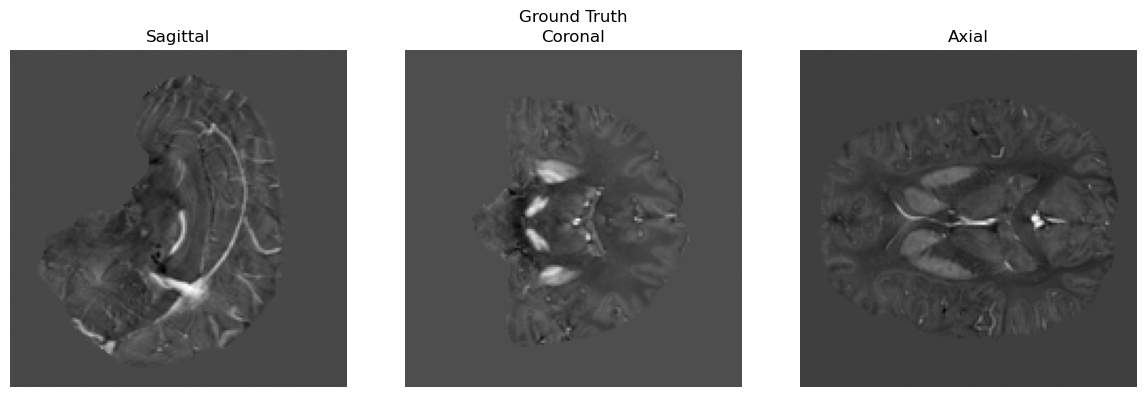

In [5]:
show_orthogonal_slices(gt, title="Ground Truth")

## Visualización de la máscara

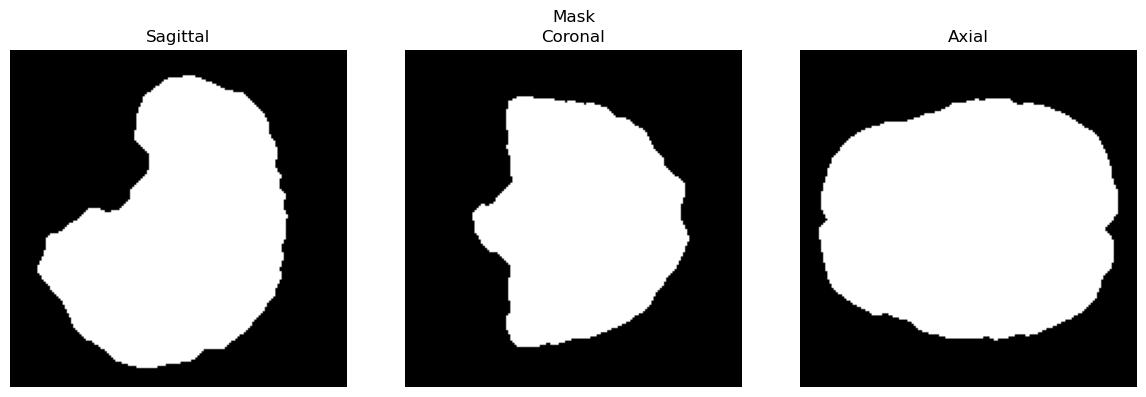

In [6]:
show_orthogonal_slices(mask.astype(float), title="Mask", cmap="gray")

## Comparación rápida entre ground truth y algunos casos

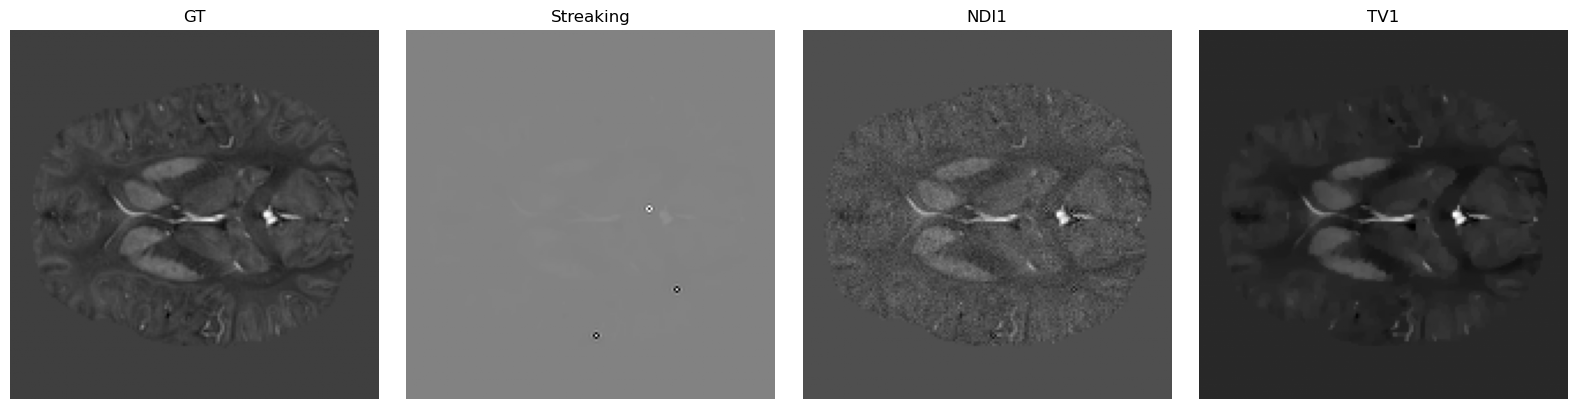

In [7]:
compare_slices(
    [gt, volumes["streaking"], volumes["reconNDI1"], volumes["recontv1"]],
    ["GT", "Streaking", "NDI1", "TV1"]
)

## Grid axial de slices

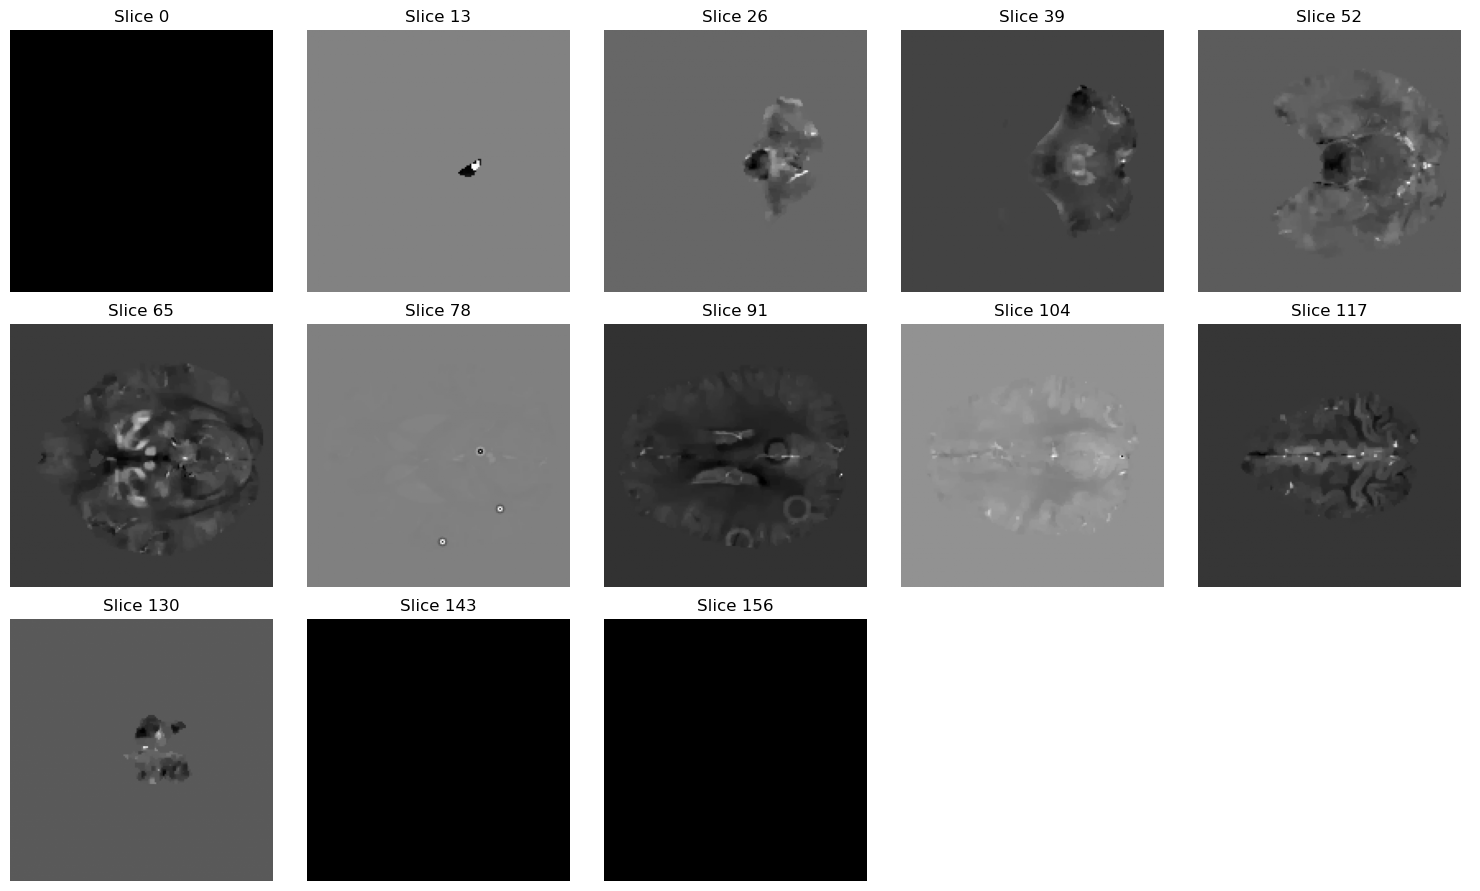

In [8]:
show_slice_grid(volumes["streaking"], axis=2, step=max(1, gt.shape[2] // 12))

## Mapas de error y perfiles

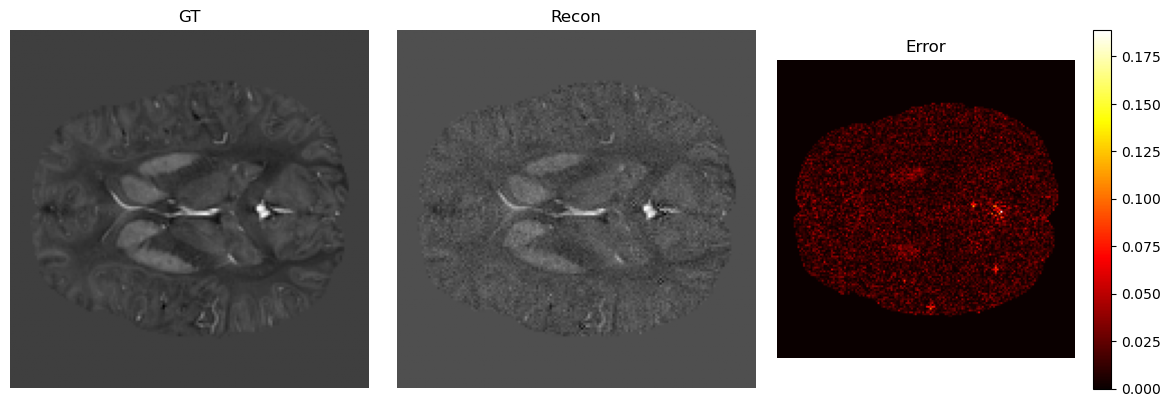

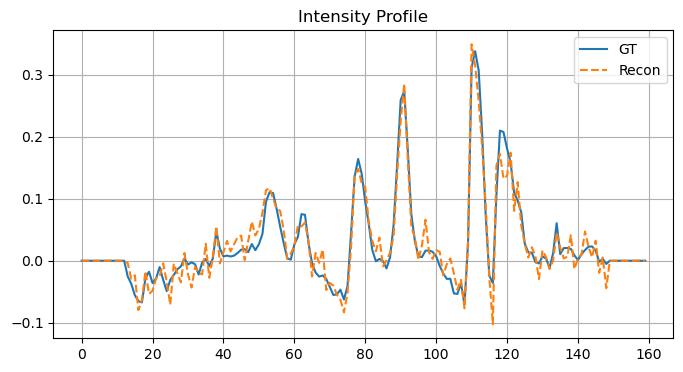

In [9]:
show_error_map(gt, volumes["reconNDI1"])
plot_intensity_profile(gt, volumes["reconNDI1"])

## Proyección MIP

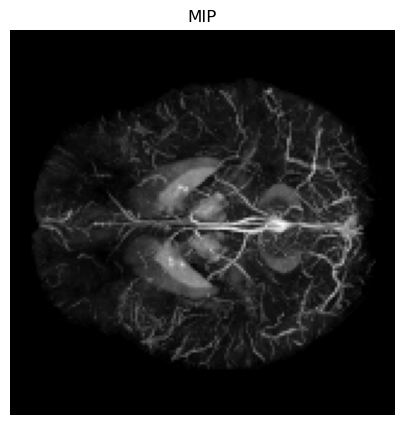

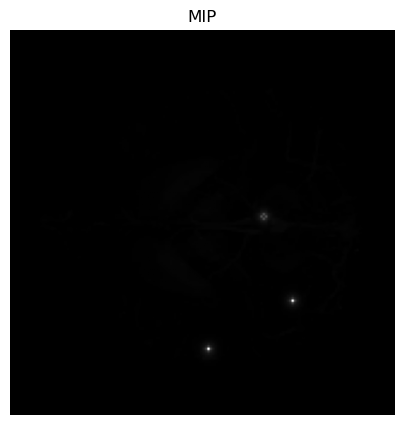

In [10]:
show_mip(gt)
show_mip(volumes["streaking"])

## Tabla automática de métricas para MRI

Se calculan:

- **RMSE** y **MAE**
- **SSIM slice-wise**
- versiones con máscara
- **WavePsi** con múltiples wavelets

In [11]:
os.makedirs(repo_root / "results" / "task2", exist_ok=True)

results = []

for name, vol in volumes.items():
    print(f"Evaluando: {name}")

    row = {"case": name}
    metrics = evaluate_pair_3d(gt, vol, mask=mask, axis=2)
    wavepsi_results = evaluate_wavepsi_family(gt, vol, mask=mask)

    row.update(metrics)
    row.update(wavepsi_results)
    results.append(row)

df_results_mri = pd.DataFrame(results)

cols_order = [
    "case",
    "rmse",
    "mae",
    "rmse_masked",
    "mae_masked",
    "ssim_slicewise",
    "ssim_slicewise_masked",
    "wavepsi_haar",
    "wavepsi_db2",
    "wavepsi_sym4",
    "wavepsi_coif1",
]

df_results_mri = df_results_mri[cols_order]
display(df_results_mri)

mri_csv = repo_root / "results" / "task2" / "mri_metrics.csv"
df_results_mri.to_csv(mri_csv, index=False)
print("Saved:", mri_csv)

Evaluando: streaking
Evaluando: reconNDI1
Evaluando: reconNDI2
Evaluando: recontv1
Evaluando: recontv2
Evaluando: recontv3


,case,rmse,mae,rmse_masked,mae_masked,ssim_slicewise,ssim_slicewise_masked,wavepsi_haar,wavepsi_db2,wavepsi_sym4,wavepsi_coif1
0,streaking,0.020372,0.002219,0.042673,0.009736,0.886842,0.671600,0.464452,0.442868,0.434923,0.443662
1,reconNDI1,0.008687,0.003226,0.018197,0.014156,0.831616,0.561714,0.461158,0.454640,0.461247,0.457429
2,reconNDI2,0.006314,0.002302,0.013227,0.010101,0.861498,0.628391,0.539880,0.526469,0.527416,0.527512
3,recontv1,0.005368,0.001928,0.011245,0.008461,0.882511,0.668521,0.470492,0.448953,0.442196,0.449787
4,recontv2,0.027513,0.002379,0.057633,0.010438,0.891852,0.681444,0.463707,0.441875,0.433830,0.442700
5,recontv3,0.049683,0.003805,0.104071,0.016696,0.930279,0.791035,0.562919,0.540846,0.534798,0.540800


Saved: /Users/pabpobar/Proyects/Courses/ProcMultiescImgs/repos/proc-multiesc-imgs/results/task2/mri_metrics.csv


In [12]:
df_results_mri.style.background_gradient(cmap="viridis")

,case,rmse,mae,rmse_masked,mae_masked,ssim_slicewise,ssim_slicewise_masked,wavepsi_haar,wavepsi_db2,wavepsi_sym4,wavepsi_coif1
0,streaking,0.020372,0.002219,0.042673,0.009736,0.886842,0.671600,0.464452,0.442868,0.434923,0.443662
1,reconNDI1,0.008687,0.003226,0.018197,0.014156,0.831616,0.561714,0.461158,0.454640,0.461247,0.457429
2,reconNDI2,0.006314,0.002302,0.013227,0.010101,0.861498,0.628391,0.539880,0.526469,0.527416,0.527512
3,recontv1,0.005368,0.001928,0.011245,0.008461,0.882511,0.668521,0.470492,0.448953,0.442196,0.449787
4,recontv2,0.027513,0.002379,0.057633,0.010438,0.891852,0.681444,0.463707,0.441875,0.433830,0.442700
5,recontv3,0.049683,0.003805,0.104071,0.016696,0.930279,0.791035,0.562919,0.540846,0.534798,0.540800


In [13]:
print("\nRanking por menor RMSE en máscara:")
display(df_results_mri.sort_values("rmse_masked"))

print("\nRanking por mayor WavePsi-Haar:")
display(df_results_mri.sort_values("wavepsi_haar", ascending=False))


Ranking por menor RMSE en máscara:


,case,rmse,mae,rmse_masked,mae_masked,ssim_slicewise,ssim_slicewise_masked,wavepsi_haar,wavepsi_db2,wavepsi_sym4,wavepsi_coif1
3,recontv1,0.005368,0.001928,0.011245,0.008461,0.882511,0.668521,0.470492,0.448953,0.442196,0.449787
2,reconNDI2,0.006314,0.002302,0.013227,0.010101,0.861498,0.628391,0.539880,0.526469,0.527416,0.527512
1,reconNDI1,0.008687,0.003226,0.018197,0.014156,0.831616,0.561714,0.461158,0.454640,0.461247,0.457429
0,streaking,0.020372,0.002219,0.042673,0.009736,0.886842,0.671600,0.464452,0.442868,0.434923,0.443662
4,recontv2,0.027513,0.002379,0.057633,0.010438,0.891852,0.681444,0.463707,0.441875,0.433830,0.442700
5,recontv3,0.049683,0.003805,0.104071,0.016696,0.930279,0.791035,0.562919,0.540846,0.534798,0.540800



Ranking por mayor WavePsi-Haar:


,case,rmse,mae,rmse_masked,mae_masked,ssim_slicewise,ssim_slicewise_masked,wavepsi_haar,wavepsi_db2,wavepsi_sym4,wavepsi_coif1
5,recontv3,0.049683,0.003805,0.104071,0.016696,0.930279,0.791035,0.562919,0.540846,0.534798,0.540800
2,reconNDI2,0.006314,0.002302,0.013227,0.010101,0.861498,0.628391,0.539880,0.526469,0.527416,0.527512
3,recontv1,0.005368,0.001928,0.011245,0.008461,0.882511,0.668521,0.470492,0.448953,0.442196,0.449787
0,streaking,0.020372,0.002219,0.042673,0.009736,0.886842,0.671600,0.464452,0.442868,0.434923,0.443662
4,recontv2,0.027513,0.002379,0.057633,0.010438,0.891852,0.681444,0.463707,0.441875,0.433830,0.442700
1,reconNDI1,0.008687,0.003226,0.018197,0.014156,0.831616,0.561714,0.461158,0.454640,0.461247,0.457429


## Comentarios guía para el análisis MRI

Conviene discutir:

- si las reconstrucciones reducen claramente el error respecto a `streaking`,
- si hay diferencias entre familias `NDI` y `TV`,
- si los rankings cambian al usar **RMSE**, **SSIM** y **WavePsi**,
- qué wavelet parece más apropiada para este contexto.

# Parte 2 — Denoising astronómico con DWT 2D

En esta parte se usan dos imágenes con comportamientos visuales distintos:

- `Moon.png`: bordes marcados, muchos detalles y alta frecuencia.
- `EX3_01.png`: estructuras más difusas y de bajo contraste.

In [14]:
moon_path = data_dir / "Moon.png"
deep_sky_path = data_dir / "EX3_01.png"

moon = load_grayscale_image(str(moon_path))
deep_sky = load_grayscale_image(str(deep_sky_path))

print("Moon:", moon.shape, moon.min(), moon.max())
print("Deep sky:", deep_sky.shape, deep_sky.min(), deep_sky.max())

Moon: (550, 550) 0.0 0.9999999999497488
Deep sky: (800, 800) 0.0 0.9999999999568965


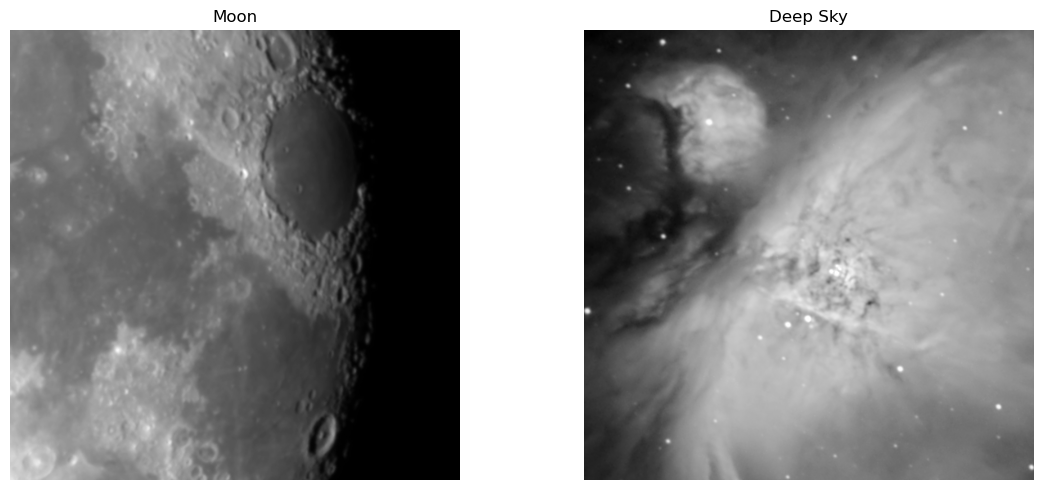

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(moon, cmap="gray")
axes[0].set_title("Moon")
axes[0].axis("off")

axes[1].imshow(deep_sky, cmap="gray")
axes[1].set_title("Deep Sky")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Ejemplo simple de degradación y reconstrucción

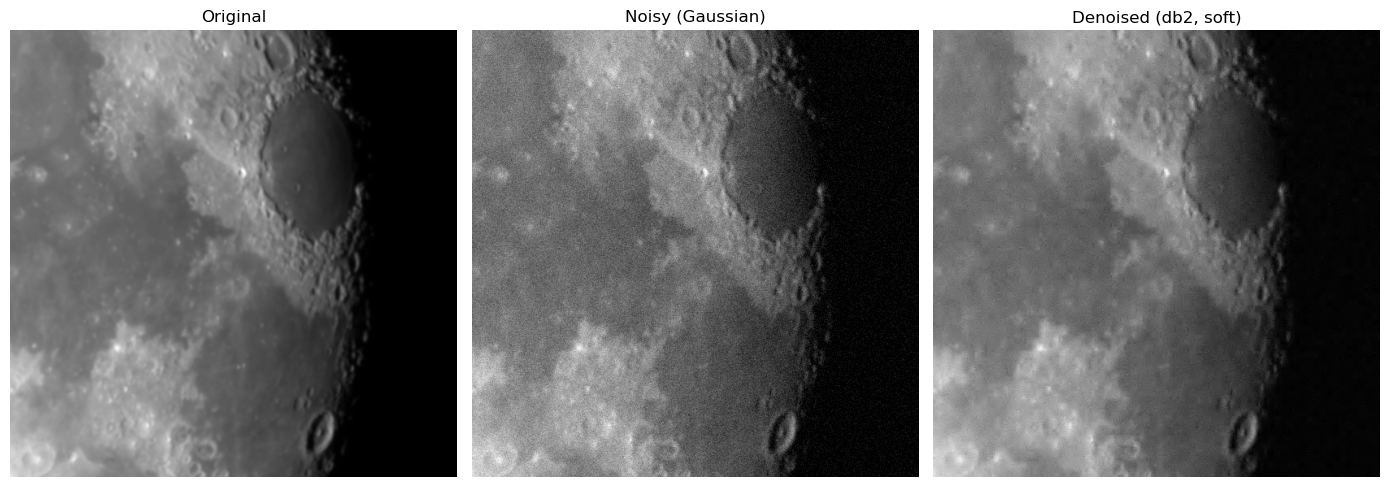

In [16]:
moon_gauss = add_gaussian_noise(moon, sigma=0.05)
moon_denoised = dwt_denoise_2d(
    moon_gauss,
    wavelet="db2",
    level=3,
    threshold=0.05,
    mode="soft"
)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(moon, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(moon_gauss, cmap="gray")
axes[1].set_title("Noisy (Gaussian)")
axes[1].axis("off")

axes[2].imshow(moon_denoised, cmap="gray")
axes[2].set_title("Denoised (db2, soft)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Tabla automática de métricas para denoising

In [17]:
images = {
    "moon": moon,
    "deep_sky": deep_sky,
}

noise_configs = [
    {"type": "gaussian", "sigma": 0.03},
    {"type": "gaussian", "sigma": 0.05},
    {"type": "uniform", "low": -0.05, "high": 0.05},
    {"type": "uniform", "low": -0.10, "high": 0.10},
]

wavelets = ["haar", "db2"]
levels = [3]
thresholds = [0.02, 0.05, 0.1]
modes = ["soft", "hard"]

rows = []

for img_name, img in images.items():
    print(f"\nImagen: {img_name}")

    for ncfg in noise_configs:

        if ncfg["type"] == "gaussian":
            noisy = add_gaussian_noise(img, sigma=ncfg["sigma"])
            noise_desc = f"gauss_sigma_{ncfg['sigma']}"
        else:
            noisy = add_uniform_noise(img, low=ncfg["low"], high=ncfg["high"])
            noise_desc = f"unif_{ncfg['low']}_{ncfg['high']}"

        print(f"  Ruido: {noise_desc}")

        base_metrics = evaluate_pair_2d(img, noisy)
        base_wavepsi = wavepsi_2d(img, noisy, wavelet="haar")

        rows.append({
            "image": img_name,
            "noise": noise_desc,
            "wavelet": "baseline",
            "level": None,
            "threshold": None,
            "mode": None,
            "rmse": base_metrics["rmse"],
            "mae": base_metrics["mae"],
            "ssim": base_metrics["ssim"],
            "wavepsi_haar": base_wavepsi,
        })

        for w in wavelets:
            for lvl in levels:
                for t in thresholds:
                    for m in modes:
                        recon = dwt_denoise_2d(
                            noisy,
                            wavelet=w,
                            level=lvl,
                            threshold=t,
                            mode=m
                        )

                        metrics = evaluate_pair_2d(img, recon)
                        wpsi = wavepsi_2d(img, recon, wavelet="haar")

                        rows.append({
                            "image": img_name,
                            "noise": noise_desc,
                            "wavelet": w,
                            "level": lvl,
                            "threshold": t,
                            "mode": m,
                            "rmse": metrics["rmse"],
                            "mae": metrics["mae"],
                            "ssim": metrics["ssim"],
                            "wavepsi_haar": wpsi,
                        })

df_denoise = pd.DataFrame(rows)

cols = [
    "image", "noise",
    "wavelet", "level", "threshold", "mode",
    "rmse", "mae", "ssim", "wavepsi_haar"
]
df_denoise = df_denoise[cols]

display(df_denoise)

denoise_csv = repo_root / "results" / "task2" / "denoising_metrics.csv"
df_denoise.to_csv(denoise_csv, index=False)
print("Saved:", denoise_csv)


Imagen: moon
  Ruido: gauss_sigma_0.03
  Ruido: gauss_sigma_0.05
  Ruido: unif_-0.05_0.05
  Ruido: unif_-0.1_0.1

Imagen: deep_sky
  Ruido: gauss_sigma_0.03
  Ruido: gauss_sigma_0.05
  Ruido: unif_-0.05_0.05
  Ruido: unif_-0.1_0.1


,image,noise,wavelet,level,threshold,mode,rmse,mae,ssim,wavepsi_haar
0,moon,gauss_sigma_0.03,baseline,NaN,NaN,None,0.028146,0.021199,0.566129,0.427977
1,moon,gauss_sigma_0.03,haar,3.0,0.02,soft,0.017952,0.014158,0.723193,0.426884
2,moon,gauss_sigma_0.03,haar,3.0,0.02,hard,0.027204,0.020751,0.577072,0.436849
3,moon,gauss_sigma_0.03,haar,3.0,0.05,soft,0.014799,0.011507,0.795679,0.322995
4,moon,gauss_sigma_0.03,haar,3.0,0.05,hard,0.020933,0.015948,0.680474,0.361164
...,...,...,...,...,...,...,...,...,...,...
99,deep_sky,unif_-0.1_0.1,db2,3.0,0.02,hard,0.057219,0.049439,0.265496,0.201131
100,deep_sky,unif_-0.1_0.1,db2,3.0,0.05,soft,0.026347,0.021351,0.630223,0.301931
101,deep_sky,unif_-0.1_0.1,db2,3.0,0.05,hard,0.053506,0.045228,0.292186,0.210662
102,deep_sky,unif_-0.1_0.1,db2,3.0,0.10,soft,0.013038,0.009676,0.907892,0.432797


Saved: /Users/pabpobar/Proyects/Courses/ProcMultiescImgs/repos/proc-multiesc-imgs/results/task2/denoising_metrics.csv


In [18]:
df_denoise.style.background_gradient(cmap="viridis")

,image,noise,wavelet,level,threshold,mode,rmse,mae,ssim,wavepsi_haar
0,moon,gauss_sigma_0.03,baseline,nan,nan,None,0.028146,0.021199,0.566129,0.427977
1,moon,gauss_sigma_0.03,haar,3.000000,0.020000,soft,0.017952,0.014158,0.723193,0.426884
2,moon,gauss_sigma_0.03,haar,3.000000,0.020000,hard,0.027204,0.020751,0.577072,0.436849
3,moon,gauss_sigma_0.03,haar,3.000000,0.050000,soft,0.014799,0.011507,0.795679,0.322995
4,moon,gauss_sigma_0.03,haar,3.000000,0.050000,hard,0.020933,0.015948,0.680474,0.361164
5,moon,gauss_sigma_0.03,haar,3.000000,0.100000,soft,0.017905,0.013181,0.770186,0.190923
6,moon,gauss_sigma_0.03,haar,3.000000,0.100000,hard,0.015876,0.012045,0.785912,0.238462
7,moon,gauss_sigma_0.03,db2,3.000000,0.020000,soft,0.017239,0.013550,0.732498,0.503924
8,moon,gauss_sigma_0.03,db2,3.000000,0.020000,hard,0.027065,0.020679,0.577533,0.436317
9,moon,gauss_sigma_0.03,db2,3.000000,0.050000,soft,0.012688,0.010046,0.818445,0.555420


In [19]:
print("\nTop-10 por menor RMSE:")
display(df_denoise.sort_values("rmse").head(10))

print("\nTop-10 por mayor SSIM:")
display(df_denoise.sort_values("ssim", ascending=False).head(10))

print("\nTop-10 por mayor WavePsi:")
display(df_denoise.sort_values("wavepsi_haar", ascending=False).head(10))


Top-10 por menor RMSE:


,image,noise,wavelet,level,threshold,mode,rmse,mae,ssim,wavepsi_haar
90,deep_sky,unif_-0.05_0.05,db2,3.0,0.10,hard,0.008064,0.005850,0.964915,0.550492
87,deep_sky,unif_-0.05_0.05,db2,3.0,0.05,soft,0.008237,0.006126,0.959806,0.538995
64,deep_sky,gauss_sigma_0.03,db2,3.0,0.10,hard,0.008629,0.006080,0.958089,0.544496
89,deep_sky,unif_-0.05_0.05,db2,3.0,0.10,soft,0.008949,0.006174,0.962722,0.550317
61,deep_sky,gauss_sigma_0.03,db2,3.0,0.05,soft,0.008969,0.006600,0.949475,0.523046
63,deep_sky,gauss_sigma_0.03,db2,3.0,0.10,soft,0.008998,0.006225,0.962349,0.548718
81,deep_sky,unif_-0.05_0.05,haar,3.0,0.05,soft,0.010715,0.007912,0.933007,0.288969
84,deep_sky,unif_-0.05_0.05,haar,3.0,0.10,hard,0.011178,0.008071,0.931207,0.229156
55,deep_sky,gauss_sigma_0.03,haar,3.0,0.05,soft,0.011216,0.008259,0.924157,0.288294
76,deep_sky,gauss_sigma_0.05,db2,3.0,0.10,soft,0.011480,0.008308,0.932240,0.475115



Top-10 por mayor SSIM:


,image,noise,wavelet,level,threshold,mode,rmse,mae,ssim,wavepsi_haar
90,deep_sky,unif_-0.05_0.05,db2,3.0,0.10,hard,0.008064,0.005850,0.964915,0.550492
89,deep_sky,unif_-0.05_0.05,db2,3.0,0.10,soft,0.008949,0.006174,0.962722,0.550317
63,deep_sky,gauss_sigma_0.03,db2,3.0,0.10,soft,0.008998,0.006225,0.962349,0.548718
87,deep_sky,unif_-0.05_0.05,db2,3.0,0.05,soft,0.008237,0.006126,0.959806,0.538995
64,deep_sky,gauss_sigma_0.03,db2,3.0,0.10,hard,0.008629,0.006080,0.958089,0.544496
61,deep_sky,gauss_sigma_0.03,db2,3.0,0.05,soft,0.008969,0.006600,0.949475,0.523046
81,deep_sky,unif_-0.05_0.05,haar,3.0,0.05,soft,0.010715,0.007912,0.933007,0.288969
76,deep_sky,gauss_sigma_0.05,db2,3.0,0.10,soft,0.011480,0.008308,0.932240,0.475115
84,deep_sky,unif_-0.05_0.05,haar,3.0,0.10,hard,0.011178,0.008071,0.931207,0.229156
58,deep_sky,gauss_sigma_0.03,haar,3.0,0.10,hard,0.011601,0.008257,0.924767,0.230417



Top-10 por mayor WavePsi:


,image,noise,wavelet,level,threshold,mode,rmse,mae,ssim,wavepsi_haar
35,moon,unif_-0.05_0.05,db2,3.0,0.05,soft,0.012447,0.009892,0.819538,0.561315
9,moon,gauss_sigma_0.03,db2,3.0,0.05,soft,0.012688,0.010046,0.818445,0.555420
90,deep_sky,unif_-0.05_0.05,db2,3.0,0.10,hard,0.008064,0.005850,0.964915,0.550492
89,deep_sky,unif_-0.05_0.05,db2,3.0,0.10,soft,0.008949,0.006174,0.962722,0.550317
63,deep_sky,gauss_sigma_0.03,db2,3.0,0.10,soft,0.008998,0.006225,0.962349,0.548718
64,deep_sky,gauss_sigma_0.03,db2,3.0,0.10,hard,0.008629,0.006080,0.958089,0.544496
38,moon,unif_-0.05_0.05,db2,3.0,0.10,hard,0.013004,0.010192,0.814629,0.541762
87,deep_sky,unif_-0.05_0.05,db2,3.0,0.05,soft,0.008237,0.006126,0.959806,0.538995
12,moon,gauss_sigma_0.03,db2,3.0,0.10,hard,0.013164,0.010214,0.815715,0.537378
61,deep_sky,gauss_sigma_0.03,db2,3.0,0.05,soft,0.008969,0.006600,0.949475,0.523046


## Selección automática de mejores configuraciones

In [20]:
best_by_rmse = (
    df_denoise[df_denoise["wavelet"] != "baseline"]
    .sort_values("rmse")
    .groupby(["image", "noise"], as_index=False)
    .first()
)

display(best_by_rmse)

,image,noise,wavelet,level,threshold,mode,rmse,mae,ssim,wavepsi_haar
0,deep_sky,gauss_sigma_0.03,db2,3.0,0.10,hard,0.008629,0.006080,0.958089,0.544496
1,deep_sky,gauss_sigma_0.05,db2,3.0,0.10,soft,0.011480,0.008308,0.932240,0.475115
2,deep_sky,unif_-0.05_0.05,db2,3.0,0.10,hard,0.008064,0.005850,0.964915,0.550492
3,deep_sky,unif_-0.1_0.1,db2,3.0,0.10,soft,0.013038,0.009676,0.907892,0.432797
4,moon,gauss_sigma_0.03,db2,3.0,0.05,soft,0.012688,0.010046,0.818445,0.555420
5,moon,gauss_sigma_0.05,db2,3.0,0.10,soft,0.017970,0.014181,0.740685,0.471391
6,moon,unif_-0.05_0.05,db2,3.0,0.05,soft,0.012447,0.009892,0.819538,0.561315
7,moon,unif_-0.1_0.1,db2,3.0,0.10,soft,0.019934,0.015982,0.713146,0.450212


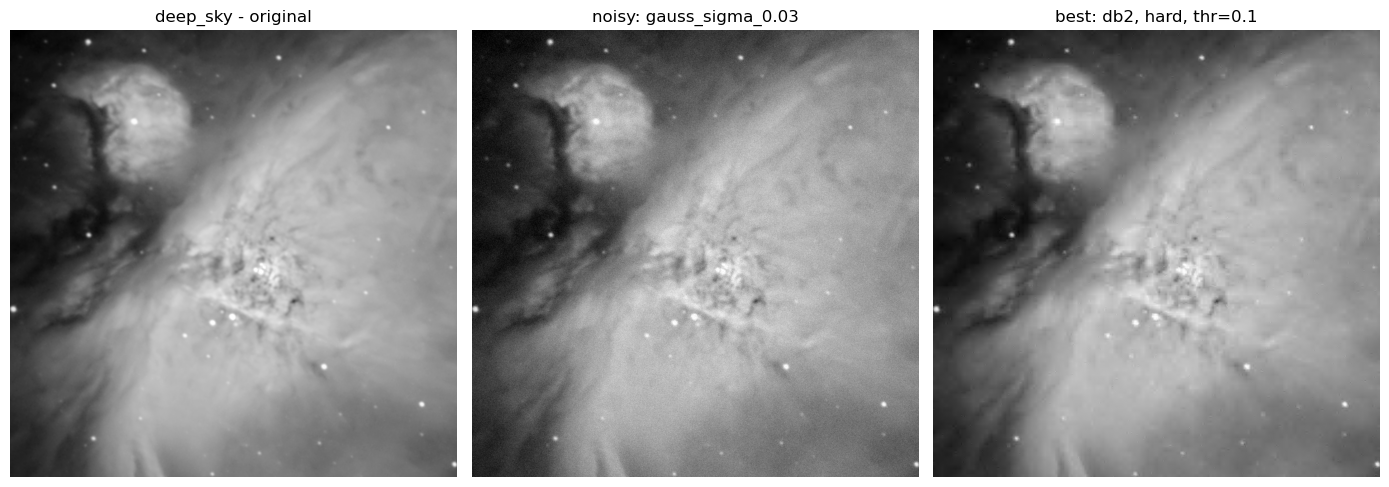

In [21]:
# Nota:
# Esta celda reconstruye una imagen ruidosa nueva al vuelo.
# Para reproducibilidad exacta fijar np.random.seed(...)
#  antes del experimento completo.

def rebuild_noisy_image(image_name, noise_desc):
    img = images[image_name]
    if noise_desc.startswith("gauss_sigma_"):
        sigma = float(noise_desc.split("_")[-1])
        return add_gaussian_noise(img, sigma=sigma)
    else:
        parts = noise_desc.replace("unif_", "").split("_")
        low, high = float(parts[0]), float(parts[1])
        return add_uniform_noise(img, low=low, high=high)

row = best_by_rmse.iloc[0]
img_name = row["image"]
noise_desc = row["noise"]
w = row["wavelet"]
lvl = int(row["level"])
thr = float(row["threshold"])
mode = row["mode"]

img = images[img_name]
noisy = rebuild_noisy_image(img_name, noise_desc)
recon = dwt_denoise_2d(noisy, wavelet=w, level=lvl, threshold=thr, mode=mode)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(img, cmap="gray")
axes[0].set_title(f"{img_name} - original")
axes[0].axis("off")

axes[1].imshow(noisy, cmap="gray")
axes[1].set_title(f"noisy: {noise_desc}")
axes[1].axis("off")

axes[2].imshow(recon, cmap="gray")
axes[2].set_title(f"best: {w}, {mode}, thr={thr}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Comentarios guía para el análisis de denoising

Conviene discutir:

- si `soft` o `hard` thresholding funciona mejor,
- si `haar` o `db2` preserva mejor detalles según el tipo de imagen,
- cómo cambia el resultado con el umbral,
- si la mejor configuración depende del tipo de contenido visual.

# Conclusión de trabajo

Este notebook deja automatizadas las dos partes de la tarea:

- evaluación MRI 3D con métricas clásicas y WavePsi,
- denoising 2D con múltiples configuraciones DWT.

A partir de las tablas y visualizaciones, ya es posible redactar el informe final con una base cuantitativa y visual consistente.